<a href="https://colab.research.google.com/github/prince-musonda/my-journey-to-artificial-intelligence/blob/main/basic_blob_multi_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# **make some data**

In [60]:
X, y = make_blobs(n_samples=1000, n_features=2, centers=4, random_state=42)

**Convert to tensor**

In [61]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)

**Split the data into training and testing set**

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)


**Visualize the data**

In [63]:
from matplotlib import pyplot as plt

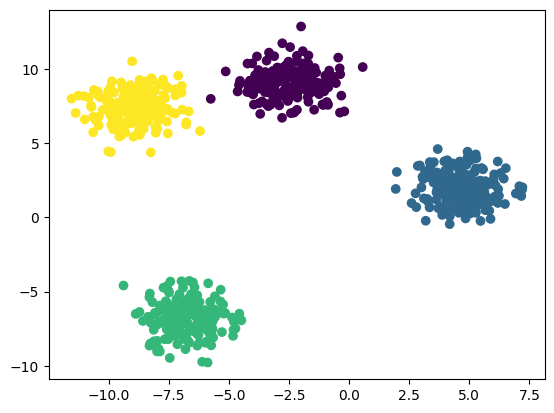

In [64]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)

# **Design Model**

In [71]:
device = 'cude' if torch.cuda.is_available() else 'cpu'

class MultiClassificationModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units = 8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        #nn.ReLu(),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        #nn.ReLu(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer_stack(x)

# **create an instance of the model**

In [88]:
model_1 = MultiClassificationModel(input_features=2, output_features=4, hidden_units=10)
model_1

MultiClassificationModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=4, bias=True)
  )
)

# **Define loss function and optimization algorithm**

In [89]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

# **Define accuracy evaluation metric**

In [90]:
def accuracy_fn(pred, true):
  correct = torch.eq(pred,true).sum().item()
  accuracy = (correct/len(true)) * 100
  return accuracy

# **Train loop**


In [91]:
# convert all data to target device i.e gpu or cpu
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)
model_1.to(device)

MultiClassificationModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=4, bias=True)
  )
)

In [92]:
for epoch in range(100):
  # put in training mode
  model_1.train()
  # forward probagation
  logits = model_1(X_train)
  pred = torch.softmax(logits, dim=1).argmax(dim=1)
  # calculate loss and accuracy
  train_loss = loss_fn(logits, y_train)
  train_accuracy = accuracy_fn(pred=pred, true=y_train)
  # back propagation
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  #### testing loop
  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test)
    test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)
    # calculate loss and accuracy
    test_loss = loss_fn(test_logits, y_test)
    test_accuracy = accuracy_fn(test_pred, y_test)

  if epoch % 5 == 0:
    print(f'epoch {epoch} ¦¦ training loss {train_loss:.5f} ¦¦ accuracy {train_accuracy}')
    print(f'test ¦¦ test loss {test_loss:.5f} ¦¦ accuracy {test_accuracy}\n')

epoch 0 ¦¦ training loss 1.15070 ¦¦ accuracy 49.875
test ¦¦ test loss 0.63973 ¦¦ accuracy 87.0

epoch 5 ¦¦ training loss 0.25163 ¦¦ accuracy 99.375
test ¦¦ test loss 0.24425 ¦¦ accuracy 98.5

epoch 10 ¦¦ training loss 0.24660 ¦¦ accuracy 88.25
test ¦¦ test loss 0.17590 ¦¦ accuracy 94.5

epoch 15 ¦¦ training loss 0.06901 ¦¦ accuracy 99.875
test ¦¦ test loss 0.06304 ¦¦ accuracy 100.0

epoch 20 ¦¦ training loss 0.04979 ¦¦ accuracy 99.875
test ¦¦ test loss 0.04583 ¦¦ accuracy 100.0

epoch 25 ¦¦ training loss 0.03855 ¦¦ accuracy 99.875
test ¦¦ test loss 0.03539 ¦¦ accuracy 100.0

epoch 30 ¦¦ training loss 0.03126 ¦¦ accuracy 99.875
test ¦¦ test loss 0.02851 ¦¦ accuracy 100.0

epoch 35 ¦¦ training loss 0.02621 ¦¦ accuracy 99.875
test ¦¦ test loss 0.02370 ¦¦ accuracy 100.0

epoch 40 ¦¦ training loss 0.02253 ¦¦ accuracy 99.875
test ¦¦ test loss 0.02018 ¦¦ accuracy 100.0

epoch 45 ¦¦ training loss 0.01974 ¦¦ accuracy 99.875
test ¦¦ test loss 0.01751 ¦¦ accuracy 100.0

epoch 50 ¦¦ training loss 